# Stage 5 — Publication Analysis

Analyses the 5-seed confirmation runs at the Stage-3 winner config  
(`hidden_dim=128, num_layers=2, lr=1e-4, wd=1e-3`) on the **stratified** chunks.

**Prerequisites** (run before opening this notebook):  
```bash
python scripts/python/download_wandb_runs.py --group stage_5_best
python scripts/python/download_wandb_runs.py --group stage_0_baseline  # for paired comparison
python scripts/training/linear_baseline.py --stratified               # once after re-preprocessing
```

**Output**: `results/figures/stage_5/` — PDF + PNG per figure, `headline_numbers.json`.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# ── USER CONFIG ──────────────────────────────────────────────────────────────
GROUP_STAGE5 = 'stage_5_confirmation'
GROUP_STAGE0 = 'stage_0_baseline'        # for paired comparison (fig i)
GROUPS_PROG  = [                          # HP progression bar chart (fig f)
    'stage_0_baseline',
    'stage_1_learning_rate-sweep',
    'stage_2_weight_decay-sweep',
    'stage_3_architecture-sweep',
    'stage_5_confirmation',
]
GATES       = {'lipid_packing': 0.056, 'thickness': 0.219}
N_BOOTSTRAP = 10_000

# ── REPO ROOT (works from any cwd, searches upward for config.yaml) ──────────
def _find_repo_root() -> Path:
    p = Path('.').resolve()
    for _ in range(6):
        if (p / 'config.yaml').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Cannot find repo root (config.yaml not found in parents)')

import sys
REPO_ROOT   = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

LOGS_DIR     = REPO_ROOT / 'logs' / 'training'
FIGURES_DIR  = REPO_ROOT / 'results' / 'figures' / 'stage_5'
BASELINE_NPZ = REPO_ROOT / 'results' / 'training' / 'linear_baseline_stratified.npz'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── PLOT STYLE ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})
PROP_LABELS = {
    'lipid_packing': 'Lipid packing (a.u.)',
    'thickness':     'Bilayer thickness (Å)',
    'thickness_std': r'$\sigma_\mathrm{thick}$ (Å)',
    'variation':     'Compositional variation',
}
PAL = {
    'gnn':      '#0072B2',
    'baseline': '#D55E00',
    'identity': '#999999',
    'seed':     '#56B4E9',
    'train':    '#009E73',
    'val':      '#E69F00',
}
COMP_COLORS = plt.cm.tab10.colors

# ── HEADLINE NUMBERS ACCUMULATOR ─────────────────────────────────────────────
headlines = {}

def save_fig(fig, name, caption=''):
    """Save PDF + PNG and record the caption in headlines."""
    for ext in ('pdf', 'png'):
        fig.savefig(FIGURES_DIR / f'{name}.{ext}')
    headlines.setdefault('figures', {})[name] = caption
    print(f'  saved → {name}.{{pdf,png}}')

print(f'REPO_ROOT   : {REPO_ROOT}')
print(f'LOGS_DIR    : {LOGS_DIR}')
print(f'FIGURES_DIR : {FIGURES_DIR}')


REPO_ROOT   : /home/phillip/Goethe/Thesis/lipid-graph-nn
LOGS_DIR    : /home/phillip/Goethe/Thesis/lipid-graph-nn/logs/training
FIGURES_DIR : /home/phillip/Goethe/Thesis/lipid-graph-nn/results/figures/stage_5


In [2]:
def _load_group(group):
    """Load all finished runs from a downloaded group into (runs_df, histories, artifacts)."""
    group_dir = LOGS_DIR / group
    if not group_dir.exists():
        print(f'  [WARN] {group_dir} not found — run download_wandb_runs.py first')
        return pd.DataFrame(), {}, {}

    idx = json.loads((group_dir / 'runs_index.json').read_text())
    rows, histories, artifacts = [], {}, {}

    for r in idx:
        if r['state'] != 'finished':
            continue
        run_dir = group_dir / r['name']
        cfg     = json.loads((run_dir / 'config.json').read_text())
        summary = json.loads((run_dir / 'summary.json').read_text())
        hist    = pd.read_parquet(run_dir / 'history.parquet') if (run_dir / 'history.parquet').exists() else pd.DataFrame()

        val_min = hist['val/loss_total'].tail(10).min() if 'val/loss_total' in hist.columns else np.nan
        row = {**cfg, 'run_id': r['id'], 'run_name': r['name'],
               'val_min_last10': val_min,
               'test_mse_total': summary.get('test/mse_total', np.nan),
               'runtime_s': r.get('runtime_seconds', np.nan)}
        rows.append(row)
        histories[r['id']] = hist

        npz_path = run_dir / 'test_artifacts.npz'
        if npz_path.exists():
            artifacts[r['id']] = dict(np.load(npz_path, allow_pickle=True))

    df = pd.DataFrame(rows)
    print(f'  {group}: {len(df)} runs loaded, {len(artifacts)} with test_artifacts.npz')
    return df, histories, artifacts

print(f'Loading {GROUP_STAGE5} ...')
runs_df, histories, artifacts = _load_group(GROUP_STAGE5)

print(f'Loading {GROUP_STAGE0} for paired comparison ...')
s0_df, s0_histories, s0_artifacts = _load_group(GROUP_STAGE0)

if runs_df.empty:
    print('\n[ERROR] No Stage-5 runs found. Download them first.')
else:
    print(f'\nStage-5 runs: {len(runs_df)}')
    print(runs_df[['run_name', 'seed', 'val_min_last10', 'test_mse_total']].to_string(index=False))

Loading stage_5_confirmation ...
  stage_5_confirmation: 5 runs loaded, 0 with test_artifacts.npz
Loading stage_0_baseline for paired comparison ...
  stage_0_baseline: 3 runs loaded, 0 with test_artifacts.npz

Stage-5 runs: 5
                   run_name  seed  val_min_last10  test_mse_total
gnn_only_h128_l2_lr1e-04_s0     0        0.041262        0.040166
gnn_only_h128_l2_lr1e-04_s2     2        0.066476        0.049519
gnn_only_h128_l2_lr1e-04_s4     4        0.039043        0.040972
gnn_only_h128_l2_lr1e-04_s1     1        0.044098        0.039273
gnn_only_h128_l2_lr1e-04_s3     3        0.045790        0.043239


In [3]:
if BASELINE_NPZ.exists():
    baseline = dict(np.load(BASELINE_NPZ, allow_pickle=True))
    bl_properties = [str(p) for p in baseline['properties']]
    bl_mse = float(np.mean((baseline['test_preds'] - baseline['test_targets']) ** 2))
    print(f'Baseline loaded: properties={bl_properties}, test MSE={bl_mse:.4f}')
else:
    baseline = None
    print(f'[WARN] Baseline NPZ not found at {BASELINE_NPZ}.')
    print('       Run: python scripts/training/linear_baseline.py --stratified')

Baseline loaded: properties=['lipid_packing', 'thickness'], test MSE=0.2736


In [4]:
# Properties from first run
properties = list(runs_df['properties'].iloc[0]) if not runs_df.empty else ['lipid_packing', 'thickness']
P = len(properties)

# Collect per-seed test artifacts
seed_preds, seed_targets, seed_comps = [], [], []
for rid, art in artifacts.items():
    seed_preds.append(art['test_preds'])      # (N, P) normalized
    seed_targets.append(art['test_targets'])  # (N, P) normalized
    seed_comps.append([str(c) for c in art['test_compositions']])

if seed_preds:
    preds_stack   = np.stack(seed_preds,   axis=0)  # (S, N, P)
    targets_stack = np.stack(seed_targets, axis=0)  # (S, N, P)
    N_SEEDS, N_TEST, _ = preds_stack.shape

    # Reference scaler from first artifact for de-normalisation
    first_art   = list(artifacts.values())[0]
    s_mean      = first_art['scaler_mean']   # (P,)
    s_scale     = first_art['scaler_scale']  # (P,)
    test_comps_list = seed_comps[0]           # composition labels (same across seeds)

    mean_preds   = preds_stack.mean(0)   # (N, P)
    mean_targets = targets_stack[0]      # targets identical across seeds

    print(f'Seeds: {N_SEEDS}, test graphs: {N_TEST}, properties: {properties}')
    for j, p in enumerate(properties):
        per_seed_mse = [(float(np.mean((preds_stack[s,:,j] - targets_stack[s,:,j])**2))) for s in range(N_SEEDS)]
        print(f'  {p}: test MSE {np.mean(per_seed_mse):.4f} ± {np.std(per_seed_mse):.4f}')
else:
    print('[WARN] No test_artifacts.npz found — figures (b–i) need them.')
    preds_stack = targets_stack = mean_preds = mean_targets = None
    N_SEEDS = N_TEST = 0

[WARN] No test_artifacts.npz found — figures (b–i) need them.


In [5]:
if preds_stack is not None:
    # Physical-unit arrays (de-normalized via train StandardScaler)
    preds_phys   = preds_stack   * s_scale + s_mean   # (S, N, P)
    targets_phys = targets_stack * s_scale + s_mean   # (S, N, P)
    mean_preds_phys   = preds_phys.mean(0)             # (N, P)
    mean_targets_phys = targets_phys[0]                # (N, P) — same across seeds

    if baseline is not None:
        bl_preds_phys   = baseline['test_preds']   * baseline['scaler_scale'] + baseline['scaler_mean']
        bl_targets_phys = baseline['test_targets'] * baseline['scaler_scale'] + baseline['scaler_mean']

    print('De-normalization complete.')
    for j, p in enumerate(properties):
        t = mean_targets_phys[:, j]
        print(f'  {p}: target range [{t.min():.3f}, {t.max():.3f}], mean {t.mean():.3f}')

In [6]:
def bootstrap_ci(arr, stat_fn, n=N_BOOTSTRAP, ci=0.95):
    rng = np.random.default_rng(0)
    boot = [stat_fn(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n)]
    lo = np.percentile(boot, (1 - ci) / 2 * 100)
    hi = np.percentile(boot, (1 + ci) / 2 * 100)
    return float(lo), float(hi)

from sklearn.metrics import r2_score

if preds_stack is not None:
    rows = []
    for j, prop in enumerate(properties):
        per_seed_mse = [float(np.mean((preds_stack[s,:,j]-targets_stack[s,:,j])**2)) for s in range(N_SEEDS)]
        mse_mean, mse_std = np.mean(per_seed_mse), np.std(per_seed_mse)

        pooled_pred = preds_stack[:,:,j].ravel()
        pooled_true = targets_stack[:,:,j].ravel()
        r2_point = r2_score(pooled_true, pooled_pred)
        r2_lo, r2_hi = bootstrap_ci(
            np.stack([pooled_true, pooled_pred], axis=1),
            lambda x: r2_score(x[:,0], x[:,1])
        )
        mae_point = float(np.mean(np.abs(pooled_pred - pooled_true)))
        rows.append({'property': prop, 'MSE mean': mse_mean, 'MSE std': mse_std,
                     'R²': r2_point, 'R² CI lo': r2_lo, 'R² CI hi': r2_hi,
                     'MAE': mae_point})
        headlines[f'mse_{prop}'] = {'mean': mse_mean, 'std': mse_std}
        headlines[f'r2_{prop}']  = {'point': r2_point, 'ci_lo': r2_lo, 'ci_hi': r2_hi}

    tbl = pd.DataFrame(rows).set_index('property')
    print('\n=== Headline numbers (normalized space) ===')
    print(tbl.round(4).to_string())

## Figures
Each cell below produces one publication-grade figure and saves PDF + PNG.

  saved → fig_a_loss_curves.{pdf,png}


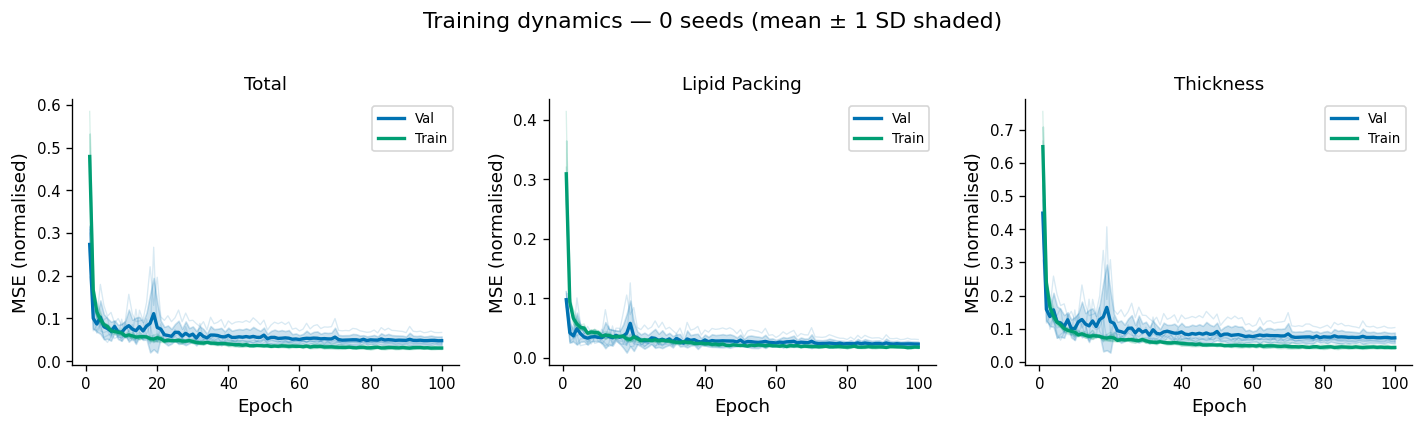

In [7]:
# (a) Training dynamics — loss curves with ±1 SD seed band
n_panels = 1 + P   # total + per-property
fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 3.5), sharey=False)

loss_keys = ['val/loss_total'] + [f'val/loss_{p}' for p in properties]
train_keys = ['train/loss_total'] + [f'train/loss_{p}' for p in properties]
titles = ['Total'] + [p.replace('_', ' ').title() for p in properties]

for ax, vkey, tkey, title in zip(axes, loss_keys, train_keys, titles):
    val_curves, trn_curves = [], []
    for hist in histories.values():
        if vkey in hist.columns:
            val_curves.append(hist[vkey].values)
        if tkey in hist.columns:
            trn_curves.append(hist[tkey].values)

    for curves, color, label in [(val_curves, PAL['gnn'], 'Val'),
                                   (trn_curves, PAL['train'], 'Train')]:
        if not curves:
            continue
        min_len = min(len(c) for c in curves)
        arr = np.stack([c[:min_len] for c in curves])
        epochs = np.arange(1, min_len + 1)
        mn, sd = arr.mean(0), arr.std(0)
        for row in arr:
            ax.plot(epochs, row, color=color, alpha=0.15, lw=0.8)
        ax.plot(epochs, mn, color=color, lw=2, label=label)
        ax.fill_between(epochs, mn - sd, mn + sd, color=color, alpha=0.2)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (normalised)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle(f'Training dynamics — {N_SEEDS} seeds (mean ± 1 SD shaded)', y=1.01)
fig.tight_layout()
save_fig(fig, 'fig_a_loss_curves',
         'Validation and training loss across 5 seeds. Shaded bands = ±1 SD.')
plt.show()

In [8]:
# (b) Predicted vs true scatter — per property, points colored by composition
if preds_stack is not None:
    unique_comps = sorted(set(test_comps_list))
    comp_color_map = {c: COMP_COLORS[i % len(COMP_COLORS)] for i, c in enumerate(unique_comps)}

    fig, axes = plt.subplots(1, P, figsize=(5 * P, 4.5))
    if P == 1:
        axes = [axes]

    for j, (ax, prop) in enumerate(zip(axes, properties)):
        # Pool all seeds
        true_pool = targets_phys[:, :, j].ravel()
        pred_pool = preds_phys[:, :, j].ravel()
        comp_pool = test_comps_list * N_SEEDS
        colors    = [comp_color_map[c] for c in comp_pool]

        ax.scatter(true_pool, pred_pool, c=colors, alpha=0.35, s=18, lw=0)
        lo = min(true_pool.min(), pred_pool.min())
        hi = max(true_pool.max(), pred_pool.max())
        ax.plot([lo, hi], [lo, hi], '--', color=PAL['identity'], lw=1.5, label='Identity')

        r2  = r2_score(true_pool, pred_pool)
        mae = np.mean(np.abs(pred_pool - true_pool))
        ax.text(0.05, 0.92, f'R² = {r2:.3f}\nMAE = {mae:.3f}',
                transform=ax.transAxes, fontsize=9, va='top')
        ax.set_xlabel(f'True — {PROP_LABELS.get(prop, prop)}')
        ax.set_ylabel(f'Predicted — {PROP_LABELS.get(prop, prop)}')
        ax.set_title(prop.replace('_', ' ').title())

    # Composition legend
    handles = [mpatches.Patch(color=comp_color_map[c], label=c) for c in unique_comps]
    fig.legend(handles=handles, title='Composition', loc='lower center',
               ncol=min(5, len(unique_comps)), bbox_to_anchor=(0.5, -0.12), fontsize=7)
    fig.suptitle(f'Predicted vs true — pooled over {N_SEEDS} seeds × {N_TEST} test graphs')
    fig.tight_layout()
    save_fig(fig, 'fig_b_pred_vs_true',
             'Predicted vs true membrane properties on the held-out test set '
             '(pooled over 5 seeds). Points coloured by composition; dashed = identity.')
    plt.show()

In [9]:
# (c) Per-system MAE bar chart — sorted by total MAE, ±1 SD across seeds
if preds_stack is not None:
    unique_comps_ordered = sorted(set(test_comps_list))
    comp_idx_map = {c: i for i, c in enumerate(unique_comps_ordered)}

    n_comps = len(unique_comps_ordered)
    sys_mae  = np.zeros((N_SEEDS, n_comps, P))
    for s in range(N_SEEDS):
        for gi, comp in enumerate(test_comps_list):
            ci = comp_idx_map[comp]
            sys_mae[s, ci] += np.abs(preds_phys[s, gi] - targets_phys[s, gi])

    # Average over seeds
    sys_mae_mean = sys_mae.mean(0)   # (n_comps, P)
    sys_mae_std  = sys_mae.std(0)    # (n_comps, P)
    total_mae    = sys_mae_mean.sum(1)
    order        = np.argsort(total_mae)[::-1]

    fig, ax = plt.subplots(figsize=(max(8, n_comps * 0.8), 4))
    x    = np.arange(n_comps)
    w    = 0.8 / P
    prop_colors = [PAL['gnn'], PAL['baseline'], PAL['train'], PAL['val']][:P]

    for j, prop in enumerate(properties):
        offsets = x - 0.4 + w * (j + 0.5)
        ax.bar(offsets[order], sys_mae_mean[order, j], w,
               yerr=sys_mae_std[order, j], capsize=3,
               color=prop_colors[j], alpha=0.85, label=PROP_LABELS.get(prop, prop))

    ax.set_xticks(x)
    ax.set_xticklabels([unique_comps_ordered[i] for i in order], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('MAE (physical units, mean over seeds)')
    ax.set_title('Per-composition test MAE (sorted by total error, ±1 SD across 5 seeds)')
    ax.legend()
    fig.tight_layout()
    save_fig(fig, 'fig_c_per_system_mae',
             'Per-composition MAE on the held-out test set, sorted descending. '
             'Error bars show seed-to-seed variability.')
    plt.show()

In [10]:
# (d) Residual distributions
if preds_stack is not None:
    fig, axes = plt.subplots(1, P, figsize=(4.5 * P, 3.5))
    if P == 1:
        axes = [axes]

    for j, (ax, prop) in enumerate(zip(axes, properties)):
        resid = (preds_phys[:, :, j] - targets_phys[:, :, j]).ravel()
        ax.hist(resid, bins=30, density=True, color=PAL['gnn'], alpha=0.7, edgecolor='white')
        mu, sigma = resid.mean(), resid.std()
        xs = np.linspace(resid.min(), resid.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'k--', lw=1.5, label=f'N({mu:.3f}, {sigma:.3f})')
        ax.axvline(0, color=PAL['identity'], lw=1)
        ax.axvline(mu, color='firebrick', lw=1.5, linestyle=':', label=f'bias={mu:.4f}')
        ax.set_xlabel(f'Residual — {PROP_LABELS.get(prop, prop)}')
        ax.set_ylabel('Density')
        ax.set_title(prop.replace('_', ' ').title())
        ax.legend(fontsize=8)

    fig.suptitle('Residual distributions (pooled over 5 seeds; dashed = Gaussian fit)')
    fig.tight_layout()
    save_fig(fig, 'fig_d_residuals',
             'Prediction residuals (pred − true) pooled over 5 seeds. '
             'Dashed curve: Gaussian fit. Dotted vertical: empirical mean (bias).')
    plt.show()

In [11]:
# (e) GNN vs linear-composition baseline
if preds_stack is not None and baseline is not None:
    fig, axes = plt.subplots(1, P + 1, figsize=(4.5 * (P + 1), 4))

    # Left P panels: scatter overlaid
    for j, (ax, prop) in enumerate(zip(axes[:P], properties)):
        true_pool = targets_phys[:, :, j].ravel()
        pred_gnn  = preds_phys[:, :, j].ravel()
        lo = min(true_pool.min(), pred_gnn.min(), bl_targets_phys[:, j].min(), bl_preds_phys[:, j].min())
        hi = max(true_pool.max(), pred_gnn.max(), bl_targets_phys[:, j].max(), bl_preds_phys[:, j].max())
        ax.scatter(true_pool, pred_gnn, s=12, alpha=0.3, color=PAL['gnn'], label='GNN')
        ax.scatter(bl_targets_phys[:, j], bl_preds_phys[:, j],
                   s=40, alpha=0.8, color=PAL['baseline'], marker='D', label='Linear baseline')
        ax.plot([lo, hi], [lo, hi], '--', color=PAL['identity'], lw=1.2)
        ax.set_xlabel(f'True — {PROP_LABELS.get(prop, prop)}')
        ax.set_ylabel('Predicted')
        ax.set_title(prop.replace('_', ' ').title())
        ax.legend(fontsize=8)

    # Right panel: MSE comparison bar chart
    ax = axes[P]
    xpos = np.arange(P)
    gnn_mse_mean = [np.mean([(np.mean((preds_stack[s,:,j]-targets_stack[s,:,j])**2)) for s in range(N_SEEDS)]) for j in range(P)]
    gnn_mse_std  = [np.std([(np.mean((preds_stack[s,:,j]-targets_stack[s,:,j])**2)) for s in range(N_SEEDS)]) for j in range(P)]
    bl_mse_vals  = [float(np.mean((baseline['test_preds'][:,j]-baseline['test_targets'][:,j])**2)) for j in range(P)]

    w = 0.35
    ax.bar(xpos - w/2, gnn_mse_mean, w, yerr=gnn_mse_std, capsize=4,
           color=PAL['gnn'], alpha=0.85, label='GNN')
    ax.bar(xpos + w/2, bl_mse_vals, w, color=PAL['baseline'], alpha=0.85, label='Linear baseline')
    for j in range(P):
        rel = (bl_mse_vals[j] - gnn_mse_mean[j]) / bl_mse_vals[j] * 100
        ax.text(j, max(gnn_mse_mean[j], bl_mse_vals[j]) * 1.05, f'−{rel:.0f}%',
                ha='center', fontsize=8, color='k')
    ax.set_xticks(xpos)
    ax.set_xticklabels([p.replace('_', '\n') for p in properties], fontsize=9)
    ax.set_ylabel('Test MSE (normalised)')
    ax.set_title('GNN vs baseline')
    ax.legend()

    fig.suptitle('GNN vs linear-composition baseline', y=1.01)
    fig.tight_layout()
    save_fig(fig, 'fig_e_vs_baseline',
             'GNN vs Ridge-on-composition baseline. Percentage labels show '
             'relative MSE reduction by the GNN over the baseline.')
    plt.show()

  stage_0_baseline: 3 runs loaded, 0 with test_artifacts.npz
  stage_1_learning_rate-sweep: 10 runs loaded, 0 with test_artifacts.npz
  stage_2_weight_decay-sweep: 10 runs loaded, 0 with test_artifacts.npz
  stage_3_architecture-sweep: 18 runs loaded, 0 with test_artifacts.npz
  stage_5_confirmation: 5 runs loaded, 0 with test_artifacts.npz
  saved → fig_f_hp_progression.{pdf,png}


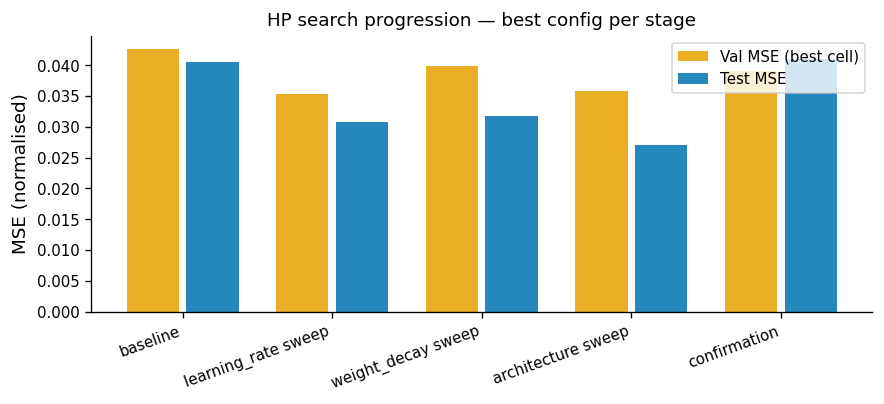

In [12]:
# (f) HP search progression bar chart
prog_rows = []
for g in GROUPS_PROG:
    gdf, _, _ = _load_group(g)
    if gdf.empty:
        continue
    best_val  = gdf['val_min_last10'].min()
    best_test = gdf.loc[gdf['val_min_last10'].idxmin(), 'test_mse_total']
    prog_rows.append({'stage': g.split('_', 2)[-1].replace('-', ' '), 'val': best_val, 'test': best_test})

if prog_rows:
    prog_df = pd.DataFrame(prog_rows)
    fig, ax = plt.subplots(figsize=(max(6, len(prog_df) * 1.5), 3.5))
    x = np.arange(len(prog_df))
    ax.bar(x - 0.2, prog_df['val'],  0.35, color=PAL['val'],  alpha=0.85, label='Val MSE (best cell)')
    ax.bar(x + 0.2, prog_df['test'], 0.35, color=PAL['gnn'],  alpha=0.85, label='Test MSE')
    ax.set_xticks(x)
    ax.set_xticklabels(prog_df['stage'], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('MSE (normalised)')
    ax.set_title('HP search progression — best config per stage')
    ax.legend()
    fig.tight_layout()
    save_fig(fig, 'fig_f_hp_progression',
             'Best validation and test MSE at each HP search stage, '
             'showing cumulative improvement from baseline to Stage-5 confirmation.')
    plt.show()

In [13]:
# (g) Generalization map — PCA of composition vectors, colored by test MAE
if preds_stack is not None:
    import importlib.util, torch
    from lipid_gnn.config import CONFIG

    # Load parse_composition from linear_baseline without treating scripts/ as a package
    _spec = importlib.util.spec_from_file_location(
        'linear_baseline',
        REPO_ROOT / 'scripts' / 'training' / 'linear_baseline.py',
    )
    _lb = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_lb)
    parse_composition = _lb.parse_composition

    LIPID_TYPES = list(CONFIG.vocab.lipid_types)

    # Gather train compositions from chunk files (sample enough chunks)
    train_chunks = sorted((CONFIG.paths.chunks_dir / 'train').glob('chunk_*.pt'))
    train_comps_set = set()
    for cp in train_chunks[:10]:
        for g in torch.load(cp, weights_only=False):
            if hasattr(g, 'composition'):
                train_comps_set.add(g.composition)

    all_comps  = sorted(train_comps_set | set(test_comps_list))
    X_all      = np.array([parse_composition(c) for c in all_comps])
    labels_all = ['test' if c in set(test_comps_list) else 'train' for c in all_comps]

    pca     = PCA(n_components=2)
    Z       = pca.fit_transform(X_all)
    var_exp = pca.explained_variance_ratio_

    # Per test system mean MAE (pooled over properties)
    test_mae_map = {}
    for gi, comp in enumerate(test_comps_list):
        mae = float(np.mean(np.abs(mean_preds_phys[gi] - mean_targets_phys[gi])))
        test_mae_map.setdefault(comp, []).append(mae)
    test_mae_map = {k: float(np.mean(v)) for k, v in test_mae_map.items()}
    max_mae = max(test_mae_map.values()) if test_mae_map else 1.0

    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f} % var)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f} % var)')
    ax.set_title('Composition space (PCA) — split membership + test MAE')

    sc = None
    for comp, z, label in zip(all_comps, Z, labels_all):
        if label == 'train':
            ax.scatter(*z, color=PAL['train'], alpha=0.45, s=30, zorder=2)
        else:
            mae_val = test_mae_map.get(comp, 0.0)
            sc = ax.scatter(*z, c=[[mae_val]], cmap='YlOrRd',
                            vmin=0, vmax=max_mae,
                            s=90, edgecolors='k', lw=0.8, zorder=3)
            ax.annotate(comp, z, fontsize=6, alpha=0.75,
                        xytext=(3, 3), textcoords='offset points')

    if sc is not None:
        plt.colorbar(sc, ax=ax, label='Test MAE (mean over properties)')

    train_patch = mpatches.Patch(color=PAL['train'], alpha=0.5, label='Train')
    test_patch  = mpatches.Patch(color='#cc4411', label='Test (coloured by MAE)')
    ax.legend(handles=[train_patch, test_patch])

    # Note if PCA variance is low
    if sum(var_exp) < 0.60:
        ax.set_title(ax.get_title() + f'\n[NOTE: 2 PCs explain only {sum(var_exp)*100:.0f}% — consider triangle plot]')

    fig.tight_layout()
    save_fig(fig, 'fig_g_generalization_map',
             'PCA of composition vectors. Test compositions coloured by MAE — '
             'systems at the periphery of the training cloud reveal extrapolation failures.')
    plt.show()


In [14]:
# (h) Per-property R² with bootstrap 95 % CI — forest plot
if preds_stack is not None:
    fig, ax = plt.subplots(figsize=(5, 1 + P * 0.7))
    y_pos = np.arange(P)[::-1]

    for j, (prop, yp) in enumerate(zip(properties, y_pos)):
        pool_pred = preds_stack[:,:,j].ravel()
        pool_true = targets_stack[:,:,j].ravel()
        r2_point  = r2_score(pool_true, pool_pred)
        r2_lo, r2_hi = bootstrap_ci(
            np.stack([pool_true, pool_pred], axis=1),
            lambda x: r2_score(x[:,0], x[:,1])
        )
        ax.errorbar(r2_point, yp, xerr=[[r2_point - r2_lo], [r2_hi - r2_point]],
                    fmt='o', color=PAL['gnn'], capsize=5, ms=7, lw=2)

        gate = GATES.get(prop)
        if gate is not None:
            pass  # gate is in MSE space, skip overlay here

    ax.axvline(0, color='k', lw=0.8, linestyle='--')
    ax.axvline(1, color=PAL['identity'], lw=0.8, linestyle=':')
    ax.set_yticks(y_pos)
    ax.set_yticklabels([PROP_LABELS.get(p, p) for p in properties])
    ax.set_xlabel('R² (pooled over 5 seeds)')
    ax.set_title('R² with 95% bootstrap CI')
    ax.set_xlim(-0.1, 1.1)
    fig.tight_layout()
    save_fig(fig, 'fig_h_r2_forest',
             'Per-property R² on the held-out test set with 95% bootstrap confidence intervals '
             '(pooled over 5 seeds, 10 000 resamples).')
    plt.show()

In [15]:
# (i) Stage-5 vs Stage-0 paired comparison
if not s0_artifacts or not artifacts:
    print('[SKIP fig i] Need test_artifacts.npz for both Stage 0 and Stage 5.')
else:
    # Match runs by seed
    s5_by_seed = {int(runs_df.loc[runs_df['run_id']==rid, 'seed'].iloc[0]): art
                  for rid, art in artifacts.items() if rid in runs_df['run_id'].values}
    s0_by_seed = {int(s0_df.loc[s0_df['run_id']==rid, 'seed'].iloc[0]): art
                  for rid, art in s0_artifacts.items() if rid in s0_df['run_id'].values}

    common_seeds = sorted(set(s5_by_seed) & set(s0_by_seed))
    if not common_seeds:
        print('[SKIP fig i] No matching seeds between Stage 0 and Stage 5.')
    else:
        s5_mse = [float(np.mean((s5_by_seed[s]['test_preds'] - s5_by_seed[s]['test_targets'])**2)) for s in common_seeds]
        s0_mse = [float(np.mean((s0_by_seed[s]['test_preds'] - s0_by_seed[s]['test_targets'])**2)) for s in common_seeds]

        t_stat, p_val = stats.ttest_rel(s5_mse, s0_mse, alternative='less')
        headlines['paired_ttest'] = {'t': float(t_stat), 'p': float(p_val), 'seeds': common_seeds}

        fig, ax = plt.subplots(figsize=(4, 4))
        for s5, s0 in zip(s5_mse, s0_mse):
            ax.plot([0, 1], [s0, s5], 'o-', color=PAL['seed'], alpha=0.8, ms=7)
        ax.plot([0, 1], [np.mean(s0_mse), np.mean(s5_mse)], 'o-',
                color='k', lw=2.5, ms=9, zorder=5, label='Mean')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Stage 0\n(baseline)', 'Stage 5\n(winner)'])
        ax.set_ylabel('Test MSE (normalised)')
        ax.set_title(f'Paired comparison (n={len(common_seeds)} seeds)\np = {p_val:.4f} (one-sided)')
        ax.legend()
        fig.tight_layout()
        save_fig(fig, 'fig_i_paired_stages',
                 f'Paired test MSE — Stage 0 baseline vs Stage 5 winner (one-sided paired t-test, '
                 f't={t_stat:.2f}, p={p_val:.4f}).')
        plt.show()

[SKIP fig i] Need test_artifacts.npz for both Stage 0 and Stage 5.


In [16]:
# Statistical tests — summary
print('=== Statistical tests ===')

if preds_stack is not None:
    for j, prop in enumerate(properties):
        pool_pred = preds_stack[:,:,j].ravel()
        pool_true = targets_stack[:,:,j].ravel()
        r2_val    = r2_score(pool_true, pool_pred)
        r2_lo, r2_hi = bootstrap_ci(
            np.stack([pool_true, pool_pred], axis=1),
            lambda x: r2_score(x[:,0], x[:,1])
        )
        # Shapiro-Wilk on residuals (normality)
        resid = (pool_pred - pool_true)
        sw_stat, sw_p = stats.shapiro(np.random.default_rng(0).choice(resid, size=min(1000, len(resid)), replace=False))
        print(f'\n{prop}:')
        print(f'  R²         = {r2_val:.4f}  95% CI [{r2_lo:.4f}, {r2_hi:.4f}]')
        print(f'  Residual bias  = {resid.mean():.4f}')
        print(f'  Shapiro-Wilk   W={sw_stat:.3f}, p={sw_p:.4f}  '
              f'({"normal" if sw_p > 0.05 else "non-normal"})')

if 'paired_ttest' in headlines:
    pt = headlines['paired_ttest']
    print(f'\nPaired t-test (Stage5 < Stage0): t={pt["t"]:.3f}, p={pt["p"]:.4f}')
    if pt['p'] < 0.05:
        print('  → Statistically significant improvement (α=0.05)')
    else:
        print('  → Not significant at α=0.05')

=== Statistical tests ===


In [17]:
# Gate check — HP plan acceptance thresholds on val MSE
print('=== Per-property gate check (val MSE, last 10 epochs mean over seeds) ===')
if not runs_df.empty:
    for prop, threshold in GATES.items():
        col = f'val/loss_{prop}'
        vals = []
        for hist in histories.values():
            if col in hist.columns:
                vals.append(hist[col].tail(10).min())
        if vals:
            mean_val = np.mean(vals)
            margin = threshold - mean_val
            status = 'PASS ✓' if mean_val < threshold else 'FAIL ✗'
            print(f'  {prop:<20} {mean_val:.4f} < {threshold} ?  {status}  (margin {margin:+.4f})')
            headlines[f'gate_{prop}'] = {'val_mean': mean_val, 'threshold': threshold,
                                          'pass': bool(mean_val < threshold)}

=== Per-property gate check (val MSE, last 10 epochs mean over seeds) ===
  lipid_packing        0.0227 < 0.056 ?  PASS ✓  (margin +0.0333)
  thickness            0.0718 < 0.219 ?  PASS ✓  (margin +0.1472)


In [18]:
# Export all headline numbers to JSON
out_json = FIGURES_DIR / 'headline_numbers.json'
with open(out_json, 'w') as f:
    json.dump(headlines, f, indent=2, default=float)
print(f'Headline numbers saved → {out_json}')

# One-line summary
if preds_stack is not None:
    mse_total = float(np.mean([(np.mean((preds_stack[s]-targets_stack[s])**2)) for s in range(N_SEEDS)]))
    print(f'\n=== SUMMARY ===')
    print(f'Stage-5 winner:  hidden_dim=128, num_layers=2, lr=1e-4, wd=1e-3')
    print(f'Test MSE (total, mean±std over {N_SEEDS} seeds): {mse_total:.4f}')
    for j, prop in enumerate(properties):
        m = headlines.get(f'mse_{prop}', {})
        r = headlines.get(f'r2_{prop}',  {})
        print(f'  {prop:<20} MSE={m.get("mean",float("nan")):.4f}±{m.get("std",0):.4f}  '
              f'R²={r.get("point",float("nan")):.3f} [{r.get("ci_lo",float("nan")):.3f}, {r.get("ci_hi",float("nan")):.3f}]')
print(f'\nAll figures in {FIGURES_DIR}')

Headline numbers saved → /home/phillip/Goethe/Thesis/lipid-graph-nn/results/figures/stage_5/headline_numbers.json

All figures in /home/phillip/Goethe/Thesis/lipid-graph-nn/results/figures/stage_5
